**Write the names of all group members (max. 5 members)**:
- Oscar Balcells Obeso
- Martín Rodríguez
- Benedict Armstrong
- Lluis Marill

When submitting your work, please follow closely the template below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import tqdm
from scipy.stats import norm
import time
import pandas as pd
from typing import List

In [2]:
comparison_df = pd.DataFrame(
    columns=[
        "model types",
        "mean loss",
        "mean std",
        "runtime (s)",
        "# params",
    ]
)

comparison_df["model types"] = ["many models", "single model", "analytical"]
comparison_df.set_index("model types", inplace=True)

# Exercise 1

### Question 1.a

Check that $ S_t = s_0 \exp \left( \sigma W_t - \frac{1}{2} \sigma^2 t \right)$ solves the Black-Scholes SDE.

We want to verify that $S_t = s_0 \exp\left( \sigma W_t - \tfrac{1}{2} \sigma^2 t \right)$ is a solution to the following SDE:

$$
dS_t = \sigma S_t \, dW_t
$$

Ito's formula for a function $f (t, W_t)$ is:

$$
dS_t = \left( \frac{\partial S_t}{\partial t} + \tfrac{1}{2} \frac{\partial^2 S_t}{\partial W_t^2} \right) dt + \frac{\partial S_t}{\partial W_t} \, dW_t
$$

The partial derivatives of $S_t$ are given as:

$$
\frac{\partial S_t}{\partial t} = s_0 e^{\sigma W_t - \tfrac{1}{2} \sigma^2 t} \left( -\tfrac{1}{2} \sigma^2 \right) = -\tfrac{1}{2} \sigma^2 S_t
$$

$$
\frac{\partial S_t}{\partial W_t} = s_0 e^{\sigma W_t - \tfrac{1}{2} \sigma^2 t} \sigma = \sigma S_t
$$

$$
\frac{\partial^2 S_t}{\partial W_t^2} = \sigma \frac{\partial S_t}{\partial W_t} = \sigma (\sigma S_t) = \sigma^2 S_t
$$

Substituting the computed derivatives:

$$
dS_t = \left( -\tfrac{1}{2} \sigma^2 S_t + \tfrac{1}{2} \sigma^2 S_t \right) dt + \sigma S_t \, dW_t = \sigma S_t d W_t
$$

which matches the given SDE when $r = 0$.

Second solution:

For $ f\left(S_t\right) = \log\left(S_t\right) $ we have: $ df = f^{'}\left(S_t\right)dS_t + \frac{1}{2}f^{''}\left(S_t\right)\left(dS_t\right)^{2} = \frac{1}{S_t}dS_t + \frac{1}{2}\left(S_t^{-2}\right)\left(S_t^{2}\sigma^{2}dt\right) = \frac{1}{S_t}\left(rS_tdt + \sigma S_tdW_t\right) - \frac{1}{2}\sigma^{2}dt = \sigma dW_t + \left(r - \frac{\sigma^{2}}{2}\right)dt $ so $ \log\left(S_t\right) =  \log\left(S_0\right) + \sigma W_t + \left(r - \frac{\sigma^{2}}{2}\right)t $ which implies that: $ S_t = s_0 \exp \left( \sigma W_t - \frac{1}{2} \sigma^2 t \right) $

### Question 1.b - Generate dataset

In [3]:
# set random seeds
np.random.seed(1)
torch.manual_seed(1)

In [4]:
TRAIN_SIZE = int(1e6)
TEST_SIZE = int(1e5)
N = 30  # number of time steps
S_0 = 1  # initial stock price
T = 30 / 365  # one month
SIGMA = 0.5
K = 1  # strike price also known as the exercise price
R = 0  # risk-free interest rate

In [5]:
class OptionsDataSet(Dataset):
    """Options dataset."""

    def __init__(self, size):
        self.size = size
        # Generate the training set
        z = np.random.normal(size=(size, N))
        self.data = np.zeros((size, N + 1))
        self.data[:, 0] = S_0
        for i in range(1, N + 1):
            self.data[:, i] = self.data[:, i - 1] * np.exp(
                -(SIGMA**2) / 2 * T / N + SIGMA * np.sqrt(T / N) * z[:, i - 1]
            )

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]

In [6]:
# Generate the training set
train_dataset = OptionsDataSet(TRAIN_SIZE)

# Generate the test set
test_dataset = OptionsDataSet(TEST_SIZE)

Text(0.5, 1.0, '10 random paths from training set')

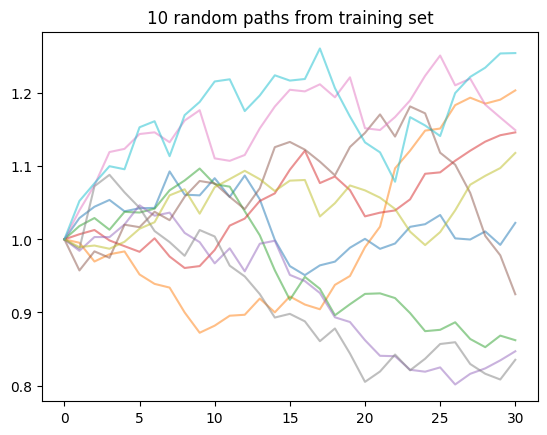

In [7]:
# plot 10 ranodm paths from training set
plt.figure()
for i in np.random.choice(TRAIN_SIZE, 10):
    plt.plot(train_dataset[i, :], alpha=0.5)

plt.title("10 random paths from training set")

### Question 1.c - Model implementation

In [8]:
# Implement the deep hedging model


class HedgingModel(torch.nn.Module):
    def __init__(self):
        super(HedgingModel, self).__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(1, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1)
        )
        self.double()

    def forward(self, x):
        return self.model(x)
        self.double()

    def forward(self, x):
        return self.model(x)


models: List[torch.nn.Module] = []
for i in range(N):
    model = HedgingModel()
    models.append(model)

# You may use and edit the code shown in demo.ipynb

### Question 1.d - Model training

In [9]:
# Implement the payoff function of a call option
def g(s_T):
    """
    Payoff function of a call option at final time T (=> European options)

    :param s_t: stock price at time T
    """
    return np.maximum(s_T - K, np.zeros_like(s_T))


def d_1(S_t, t):
    """
    See Eq. 3 ff.

    :param S_t: stock price at time t
    :param t: time
    """
    factor = 1 / (SIGMA * np.sqrt(T - t))
    return factor * (np.log(S_t / K) + (0 + SIGMA**2 / 2) * (T - t))


def d_2(S_t, t):
    """
    See Eq. 3 ff.

    :param S_t: stock price at time t
    :param t: time
    """
    return d_1(S_t, t) - SIGMA * np.sqrt(T - t)


# Implement a function that returns the Black-Scholes price of a call option with given strike and maturity


def C(S_t, t):
    """
    Value of European call option at time t given stock price S_t

    Implement Eq. 3 from the task description

    :param S_t: stock price at time t
    :param t: time
    """
    return norm.cdf(d_1(S_t, t)) * S_t - norm.cdf(d_2(S_t, t)) * K * np.exp(R * (T - t))


def p(s_t):
    """
    Risk neutral price of a call option

    :param s_t: current stock price
    """
    return C(s_t, 0)


def loss_function(H: torch.Tensor, S: torch.Tensor):
    """

    :param H: model output of shape (batch_size, N)
    :param S: stock prices of shape (batch_size, N + 1)
    """

    return torch.mean(
        (g(S[:, -1]) - p(S[:, 0].numpy()) - torch.sum(H * (S[:, 1:] - S[:, :-1]), dim=1)) ** 2
    )

In [10]:
### Training preperation

# Define training hyperparameters
n_epochs = 5
lr = 1e-2
batch_size = 1000
milestones = [75]

# Instantiate an optimizer (i.e. a (Stochastic) Gradient Descent algorithm)
all_params = []
for model in models:
    all_params += list(model.parameters())

optimizer = torch.optim.Adam(all_params, lr=lr)

# Instantiate a scheduler to decrease the learning rate during training according to a pre-defined rule
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=milestones, gamma=0.1
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

Epoch 5/5: 100%|██████████| 1000/1000 [01:15<00:00, 13.17it/s, loss=8.31e-5]


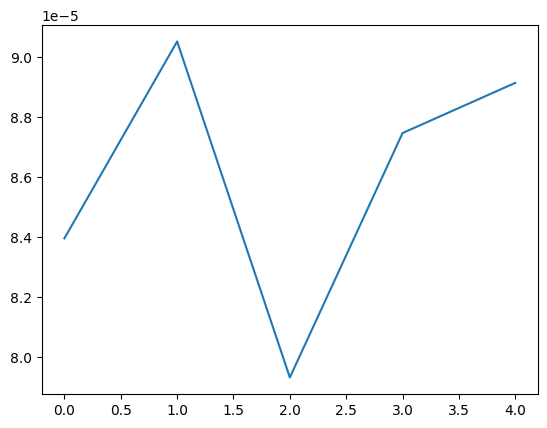

In [11]:
for model in models:
    model.train()
# Train the model
losses = []
for epoch in range(n_epochs):
    # At each epoch iterate over batches
    training_loop = tqdm.tqdm(train_loader, total=len(train_loader))
    training_loop.set_description(f"Epoch {epoch + 1}/{n_epochs}")
    for X_batch in training_loop:
        H = []
        for i, model in enumerate(models):
            H.append(model(torch.log(X_batch[:, i].unsqueeze(1)).double()))

        H = torch.stack(H, dim=1).squeeze(2)
        # compute training loss on batch
        loss = loss_function(H, X_batch)
        # compute gradient of training loss wrt parameters
        loss.backward()
        # do one gradient step
        optimizer.step()
        # reset the computational graph
        optimizer.zero_grad()

        # Print loss in the progression bar
        if training_loop.n % 10 == 0:
            training_loop.set_postfix(loss=loss.item())

    # decrease learning rate according to scheduler's settings
    scheduler.step()

    # save training loss for plotting
    losses.append(loss.item())

plt.plot(losses, label="Training loss")
plt.show()

### Question 1.e - Model evaluation

In [12]:
def loss_function_eval(H: torch.Tensor, S: torch.Tensor):
    """

    :param H: model output of shape (batch_size, N)
    :param S: stock prices of shape (batch_size, N + 1)
    """

    return g(S[:, -1]) - p(S[:, 0].numpy()) - torch.sum(H * (S[:, 1:] - S[:, :-1]), dim=1)

In [13]:
def evaluate_models(models, test_loader):
    """
    Evaluate the model on the test set

    :param test_loader: test data loader
    """

    losses = []
    with torch.no_grad():
        for X_batch in test_loader:
            H = []

            for i, model in enumerate(models):
                H.append(model(torch.log(X_batch[:, i].unsqueeze(1)).double()))

            H = torch.stack(H, dim=1).squeeze(2)
            loss = loss_function_eval(H, X_batch)
            losses.append(loss)

    return torch.cat(losses).detach().numpy()

mean -4.9892438606756555e-05
standard deviation 0.009177663793038434


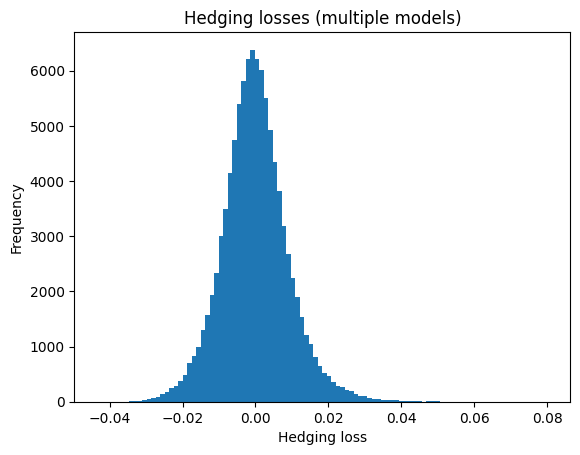

In [14]:
# Evaluate the hedging losses on the test set

# Compute the hedging losses on the test set
hedging_losses = []


start = time.time()

hedging_losses = evaluate_models(models, test_loader)

# Plot a histogram of the hedging losses and print mean and standard deviation
plt.figure()
plt.hist(hedging_losses, bins=100)
plt.title("Hedging losses (multiple models)")
plt.xlabel("Hedging loss")
plt.ylabel("Frequency")

end = time.time()
many_run_time = end - start
many_mean = np.mean(hedging_losses)
many_std = np.std(hedging_losses)

comparison_df.loc["many models", "mean loss"] = many_mean
comparison_df.loc["many models", "mean std"] = many_std
comparison_df.loc["many models", "runtime (s)"] = many_run_time
comparison_df.loc["many models", "# params"] = sum(p.numel() for p in all_params)

print("mean", many_mean)
print("standard deviation", np.std(hedging_losses))

A few questions for you to consider...

Have you trained your model well?
- Are the losses centered on zero?
- Is their standard deviation sufficiently small?

How can you improve performance?
- train for more epochs
- try different batch sizes
- try a different learning rate
- use a learning rate scheduler (see https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)
- try a different activation function
- change the networks' architectures (more/less hidden neurons, more/less hidden layers)
- reduce/increase the learning rate
- implement regularization (use the `weight_decay` argument in the optimizer)
- implement batch-normalization (see https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
- experiment with different optimizers
- ask in the forum

Losses are centered on 0 and the standard deviation is small so we are training well.

# Exercise 2

### Question 2.a - Compute analytical solution

Show a **step-by-step** derivation of the analytical hedging strategy:

\begin{align*}
H^{\text{BS}}_t(s) & = \frac{\partial C(s, t)}{\partial s} \\
& = \ldots
\end{align*}

$$ H^{\text{BS}}_t(s) =  \frac{\partial C(s, t)}{\partial s} = \frac{\partial (\Phi(d_{+}(s))s-\Phi(d_{-}(s))Ke^{-r(T-t)})}{\partial s} $$
$$= \Phi\left(d_+\left(s\right)\right) + s\Phi^{'}\left(d_+\left(s\right)\right)d_+^{'}\left(s\right)  - Ke^{-r\left(T-t\right)}\Phi^{'}\left(d_-\left(s\right)\right)d_-^{'}\left(s\right) $$
Let's call $\Phi'$, $f$. Since $\Phi$ is the standard normal cdf, we know $f$ is the standard normal pdf. Using the fact that $d_+^{'} = d_-^{'}$ (because their difference doesn't depend on $s$)
$$= \Phi\left(d_+\left(s\right)\right) + sf\left(d_+\left(s\right)\right)d_+^{'}\left(s\right)  - Ke^{-r\left(T-t\right)}f\left(d_-\left(s\right)\right)d_+^{'}\left(s\right) $$

Calculating $d'_{+}(s)$ we get $ \frac{1}{\sigma \sqrt{T-t}} \frac{1}{s} = \frac{1}{s\sigma \sqrt{T-t}}$, so we get

$$ H^{\text{BS}}_t(s) = \Phi\left(d_+\left(s\right)\right) + sf\left(d_+\left(s\right)\right)\frac{1}{s\sigma \sqrt{T-t}}  - Ke^{-r\left(T-t\right)}f\left(d_-\left(s\right)\right)\frac{1}{s\sigma \sqrt{T-t}} $$
$$= \Phi\left(d_+\left(s\right)\right) + f\left(d_+\left(s\right)\right)\frac{1}{\sigma \sqrt{T-t}}  - Ke^{-r\left(T-t\right)}f\left(d_-\left(s\right)\right)\frac{1}{s\sigma \sqrt{T-t}}$$

where $f$ is the standard gaussian pdf

### Question 2.b - Analytical solution evaluation

In [15]:
# Implement the formula you found
def analytical_sol(s, t):
    # We can forget about the exponential term because r = 0
    return (
        norm.cdf(d_1(s, t))
        + norm.pdf(d_1(s, t)) / (SIGMA * np.sqrt(T - t))
        - K * norm.pdf(d_2(s, t)) / (s * SIGMA * np.sqrt(T - t))
    )


# Evaluate the losses of the analytical hedging strategies on the test set

In [16]:
def evaluate_analytical_hedge(test_loader):
    """
    Evaluate the analytical hedge on the test set

    :param test_loader: test data loader
    """

    losses = []
    all_timesteps = np.arange(0, N) / N * T
    for X_batch in tqdm.tqdm(test_loader):
        X = X_batch.detach().numpy()

        H = analytical_sol(X[:, :-1], all_timesteps)

        loss = g(X[:, -1]) - p(X[:, 0]) - np.sum(H * (X[:, 1:] - X[:, :-1]), axis=-1)

        losses.append(loss)

    return np.concatenate(losses)




100%|██████████| 100/100 [00:01<00:00, 56.75it/s]


mean -5.922148203587456e-05
standard deviation 0.008921755329168788


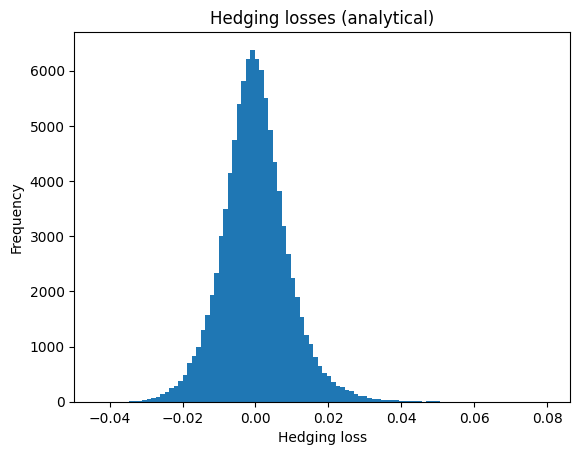

In [17]:

start = time.time()

analytical_losses = evaluate_analytical_hedge(test_loader)
# Plot a histogram of the hedging losses and print mean and standard deviation
plt.figure()
plt.hist(hedging_losses, bins=100)
plt.title("Hedging losses (analytical)")
plt.xlabel("Hedging loss")
plt.ylabel("Frequency")

end = time.time()
analytical_time = end - start
analytical_mean = np.mean(analytical_losses)
analytical_std = np.std(analytical_losses)

comparison_df.loc["analytical", "mean loss"] = analytical_mean
comparison_df.loc["analytical", "mean std"] = analytical_std
comparison_df.loc["analytical", "runtime (s)"] = analytical_time
comparison_df.loc["analytical", "# params"] = 0

print("mean", analytical_mean)
print("standard deviation", analytical_std)

**Something to think about**: in the Black-Scholes model every option can be perfectly hedged using its analytical hedging strategy.
But the analytical solution you have computed does not give zero losses. Can you explain why?

The analytical solution gives the perfect answer for a continous time enviorment, but we are in a discrete time enviroment.

### Question 2.c - Hedging losses comparison

How does your deep hedging model compare with the analytical solution?
- If it's worse, you must improve its performance (see checklist above)

The losses of our hedging models have approximately the same standard deviation as the losses of the analytical model, so their performance is approximately the same.

### Question 2.d - Learned strategy comparison

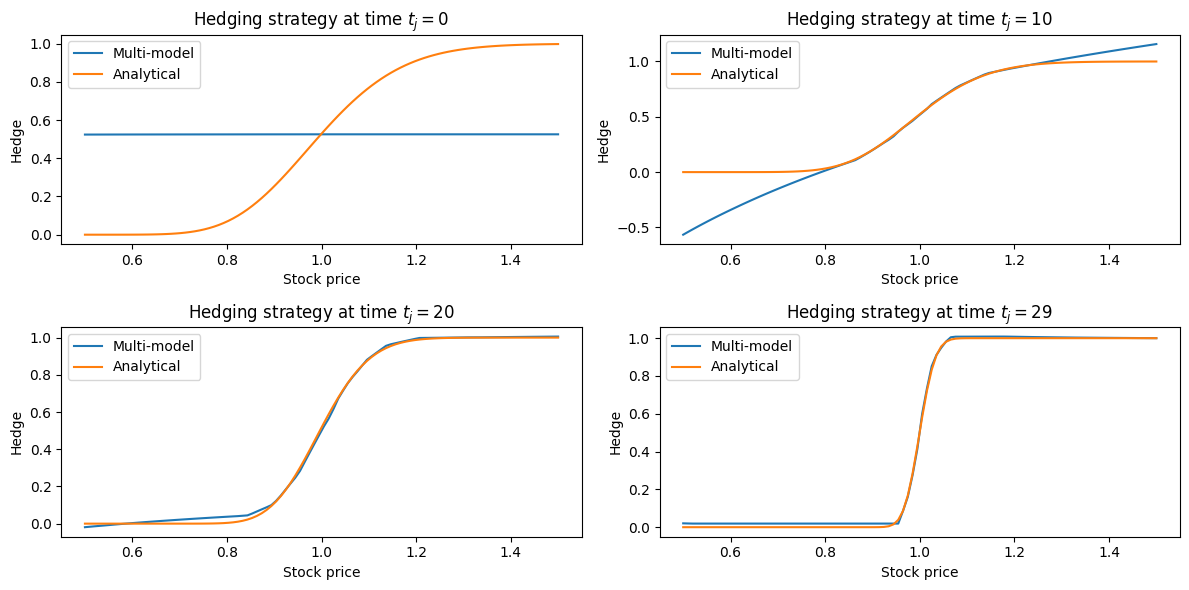

In [18]:
# Plot both the neural network strategies and the analytical hedging strategies

fig, axs = plt.subplots(2, 2, figsize=(12, 6))

for i, t_j in enumerate([0, 10, 20, 29]):
    ax = axs.flatten()[i]

    # plot s |-> H(s, t_j) for multi-model and analytical hedging strategies for s in [0.5, 1.5]
    s = np.linspace(0.5, 1.5, 100)
    model = models[t_j]
    H_model = model(torch.log(torch.tensor(s).unsqueeze(1)).double()).detach().numpy()
    ax.plot(s, H_model, label="Multi-model")

    H_analytical = analytical_sol(s, t_j / N * T)
    ax.plot(s, H_analytical, label="Analytical")

    ax.set_title(f"Hedging strategy at time $t_j={t_j}$")
    ax.set_xlabel("Stock price")
    ax.set_ylabel("Hedge")

    ax.legend()

plt.tight_layout()
plt.show()


Q: For what times $t_j$ are the two functions most similar? \
A: The two functions are most similar at the end of the time period, when the option is about to expire.

Q: Why? \
A: Since there is very little time until option expiry, the stock price can change very little between now and expiry. Because there is so little uncertainty, all decent solutions will behave in very similiar ways.

# Exercise 3

### Question 3.a - Model implementation

In [19]:
# Implement the new deep hedging model
# Implement the deep hedging model
class HedgingModelTime(torch.nn.Module):
    def __init__(self):
        super(HedgingModelTime, self).__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(2, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1),
        )
        self.double()

    def forward(self, x):
        return self.model(x)


# You may use and edit the code shown in demo.ipynb

### Question 3.b - Model training

Epoch 5/5: 100%|██████████| 1000/1000 [06:34<00:00,  2.53it/s, loss=8.75e-5]


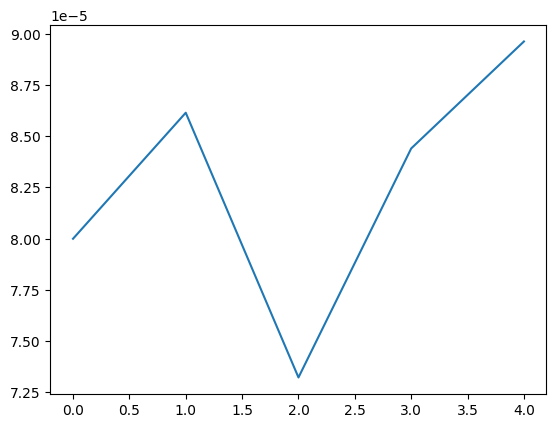

In [20]:
# Train the new deep hedging model
# Train the model

# n_epochs = 5 # number of epochs uncomment if different from other training
# lr = 1e-2
# milestones = [75]

time_model = HedgingModelTime()
losses = []

optimizer = torch.optim.Adam(time_model.parameters(), lr=lr)

# Instantiate a scheduler to decrease the learning rate during training according to a pre-defined rule
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=milestones, gamma=0.1
)

# Train the model
losses = []
for epoch in range(n_epochs):
    # At each epoch iterate over batches
    training_loop = tqdm.tqdm(train_loader, total=len(train_loader))
    training_loop.set_description(f"Epoch {epoch + 1}/{n_epochs}")
    for X_batch in training_loop:
        M = X_batch.shape[0]

        t = torch.arange(0, N) / N * T
        time_input = torch.sqrt(T - t)
        time_input = time_input.repeat(M, 1)
        s_input = torch.log(X_batch[:, :N])
        #full_input = torch.stack((s_input, time_input)).reshape(-1, 2)
        full_input = torch.stack((s_input, time_input),dim=2)
        model_output = time_model(full_input)
        H = model_output.squeeze(-1)

        # compute training loss on batch
        loss = loss_function(H, X_batch)
        # compute gradient of training loss wrt parameters
        loss.backward()
        # do one gradient step
        optimizer.step()
        # reset the computational graph
        optimizer.zero_grad()

        # Print loss in the progression bar
        if training_loop.n % 10 == 0:
            training_loop.set_postfix(loss=loss.item())

    # decrease learning rate according to scheduler's settings
    scheduler.step()

    # save training loss for plotting
    losses.append(loss.item())

plt.plot(losses, label="Training loss time model")

### Question 3.c - Model evaluation

In [21]:
def evaluate_time_model(model, test_loader):
    """
    Evaluate the model on the test set

    :param test_loader: test data loader
    """

    losses = []
    with torch.no_grad():
        for X_batch in test_loader:
            M = X_batch.shape[0]
            t = torch.arange(0, N) / N * T
            time_input = torch.sqrt(T - t)
            time_input = time_input.repeat(M, 1)
            s_input = torch.log(X_batch[:, :N])
            #full_input = torch.stack((s_input, time_input)).reshape(-1, 2)
            full_input = torch.stack((s_input, time_input),dim=2)
            model_output = time_model(full_input)
            H = model_output.squeeze(-1)
            loss = loss_function_eval(H, X_batch)
            losses.append(loss)

    return torch.cat(losses).detach().numpy()

mean -5.6996583774530494e-05
standard deviation 0.009250567669734847


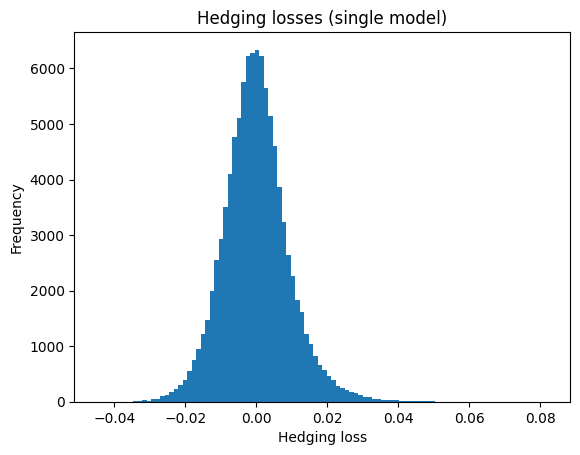

In [22]:
# Evaluate the hedging losses on the test set

# Compute the hedging losses on the test set


hedging_losses = []

start = time.time()

hedging_losses = evaluate_time_model(time_model, test_loader)

# Plot a histogram of the hedging losses and print mean and standard deviation
plt.figure()
plt.hist(hedging_losses, bins=100)
plt.title("Hedging losses (single model)")
plt.xlabel("Hedging loss")
plt.ylabel("Frequency")

end = time.time()
time_run_time = end - start
time_mean = np.mean(hedging_losses)
time_std = np.std(hedging_losses)

comparison_df.loc["single model", "mean loss"] = time_mean
comparison_df.loc["single model", "mean std"] = time_std
comparison_df.loc["single model", "runtime (s)"] = time_run_time
comparison_df.loc["single model", "# params"] = sum(
    p.numel() for p in time_model.parameters()
)


print("mean", np.mean(hedging_losses))
print("standard deviation", np.std(hedging_losses))

### Question 3.d - Model comparison

In [23]:
# Compare with the first deep hedging model (Exercise 1)
# Keep the comparison fair: evaluate run-time, performance and number of parameters.
comparison_df

,mean loss,mean std,runtime (s),# params
model types,,,,
many models,-0.00005,0.009178,2.303678,66270
single model,-0.000057,0.009251,16.842383,12193
analytical,-0.000059,0.008922,1.932409,0


The analytical solution is both the fastest and the best performing (though all performances are pretty much equal). The single model is slowest, because we added a lot of layer's trying to get it's performance to same level as the others.

The many-models model performs very well and fast, but has the disadvantage of needing a different model for every discrete time step, meaning if we have a large number of discrete time steps (either because the options take a long time to expire or because we are being very granular with time) we will have to optimize a very large number of parameters.

Because of this, plus the fact that the analytical model will perform better if we the more granular we are with time (because we are closer to the continous time case), I would choose the analytical model in cases where there are a large number of discrete time steps and the many-models model otherwise.


